# Limpeza e Tratamento dos Dados

### 1. Setup (Bibliotecas)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Bibliotecas carregadas")

Bibliotecas carregadas


### 2. Carregar Ficheiros

In [2]:
# Upload
from google.colab import files
uploaded = files.upload()

Saving richmond.csv to richmond (3).csv
Saving philadelphia.csv to philadelphia (3).csv
Saving lancaster.csv to lancaster (3).csv
Saving baltimore.csv to baltimore (3).csv


In [3]:
# Ler Dados
baltimore = pd.read_csv("baltimore.csv")
lancaster = pd.read_csv("lancaster.csv")
philadelphia = pd.read_csv("philadelphia.csv")
richmond = pd.read_csv("richmond.csv")

print("Dados carregados")

Dados carregados


### 3. Explorar os Dados

#### 3.1. Valores Ausentes

In [4]:
# Contagem de Valores Ausentes
missing = pd.DataFrame({
    "Baltimore": baltimore.isnull().sum(),
    "Lancaster": lancaster.isnull().sum(),
    "Philadelphia": philadelphia.isnull().sum(),
    "Richmond": richmond.isnull().sum()
})

missing

,Baltimore,Lancaster,Philadelphia,Richmond
Date,0,0,0,0
Num_Employees,0,0,0,0
Num_Customers,0,0,0,0
Pct_On_Sale,1,1,1,1
TouristEvent,0,0,0,0
Sales,0,0,0,0


In [5]:
# Valores Ausentes em Detalhe
for name, df in [
    ("Baltimore", baltimore),
    ("Philadelphia", philadelphia),
    ("Richmond", richmond),
    ("Lancaster", lancaster)
]:
    print(f"\n{name}:")
    display(df[df.isnull().any(axis=1)])


Baltimore:


,Date,Num_Employees,Num_Customers,Pct_On_Sale,TouristEvent,Sales
658,2014-04-20,6,0,NaN,No,21268



Philadelphia:


,Date,Num_Employees,Num_Customers,Pct_On_Sale,TouristEvent,Sales
658,2014-04-20,15,0,NaN,No,51806



Richmond:


,Date,Num_Employees,Num_Customers,Pct_On_Sale,TouristEvent,Sales
658,2014-04-20,5,0,NaN,No,15178



Lancaster:


,Date,Num_Employees,Num_Customers,Pct_On_Sale,TouristEvent,Sales
658,2014-04-20,7,0,NaN,No,30812


Foi identificado apenas um valor ausente por loja na variável Pct_On_Sale.
Dado que o número de valores em falta é residual, vamos optar por tratar estes valores
utilizando interpolação e forward fill, garantindo a continuidade temporal dos dados

#### 3.2. Outliers

In [6]:
# Análise de Outliers
for name, df in [
    ("Baltimore", baltimore),
    ("Lancaster", lancaster),
    ("Philadelphia", philadelphia),
    ("Richmond", richmond)
]:

    print(f"\n{name} - Intervalos:")
    print("Num_Customers:", df['Num_Customers'].min(), "-", df['Num_Customers'].max())
    print("Num_Employees:", df['Num_Employees'].min(), "-", df['Num_Employees'].max())
    print("Sales:", df['Sales'].min(), "-", df['Sales'].max())
    print("Date:", df['Date'].min(), "-", df['Date'].max())


Baltimore - Intervalos:
Num_Customers: 0 - 1088
Num_Employees: 0 - 83
Sales: 0 - 171345
Date: 2012-07-01 - 2014-06-14

Lancaster - Intervalos:
Num_Customers: 0 - 1862
Num_Employees: 0 - 190
Sales: 0 - 298630
Date: 2012-07-01 - 2014-06-14

Philadelphia - Intervalos:
Num_Customers: 0 - 1693
Num_Employees: 0 - 184
Sales: 0 - 252073
Date: 2012-07-01 - 2014-06-14

Richmond - Intervalos:
Num_Customers: 0 - 596
Num_Employees: 0 - 51
Sales: 0 - 83973
Date: 2012-07-01 - 2014-06-14


In [7]:
#  Contagem de Outliers
for name, df in {
    "Baltimore": baltimore,
    "Lancaster": lancaster,
    "Philadelphia": philadelphia,
    "Richmond": richmond
}.items():

    print(f"\n{name} - Outliers:")

    for col in ['Num_Customers', 'Num_Employees', 'Sales']:

        q_low = df[col].quantile(0.01)
        q_high = df[col].quantile(0.99)

        outliers = df[(df[col] < q_low) | (df[col] > q_high)]

        print(f"{col}: {len(outliers)} outliers")


Baltimore - Outliers:
Num_Customers: 16 outliers
Num_Employees: 14 outliers
Sales: 16 outliers

Lancaster - Outliers:
Num_Customers: 16 outliers
Num_Employees: 12 outliers
Sales: 16 outliers

Philadelphia - Outliers:
Num_Customers: 16 outliers
Num_Employees: 13 outliers
Sales: 16 outliers

Richmond - Outliers:
Num_Customers: 16 outliers
Num_Employees: 11 outliers
Sales: 16 outliers


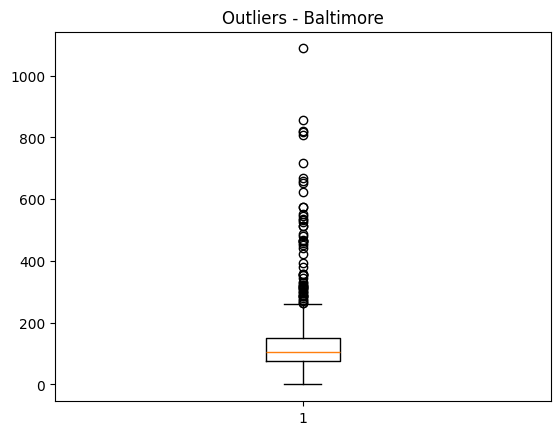

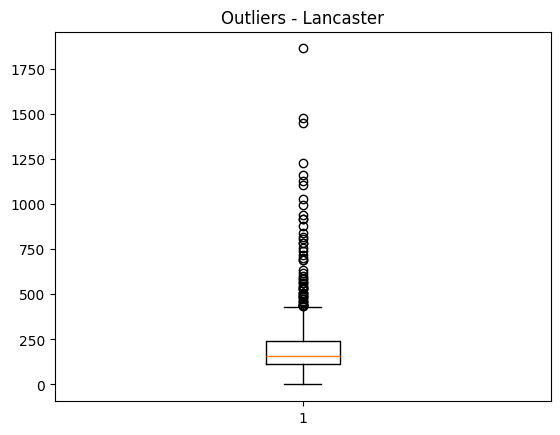

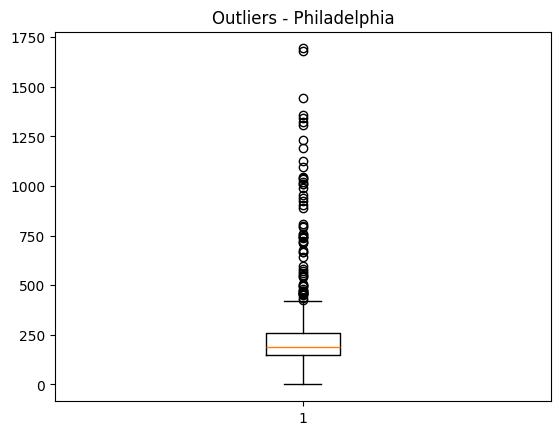

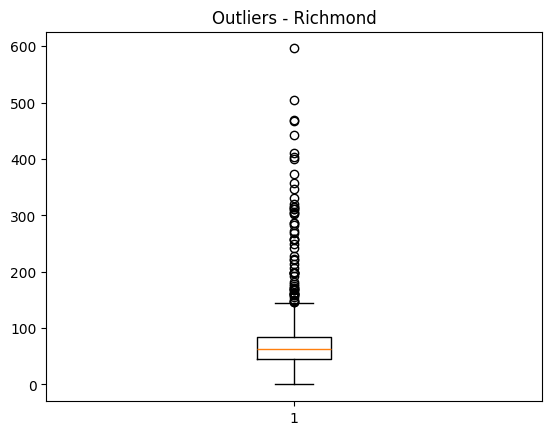

In [8]:
# Verificar Outliers
for name, df in {
    "Baltimore": baltimore,
    "Lancaster": lancaster,
    "Philadelphia": philadelphia,
    "Richmond": richmond
}.items():

    plt.figure()
    plt.boxplot(df['Num_Customers'])
    plt.title(f"Outliers - {name}")
    plt.show()

  Os valores extremos foram identificados com base em percentis (1% e 99%).
  Embora estes valores possam representar situações reais (como picos de procura e vendas, variações no número de empregados) ,
  podem distorcer o desempenho dos modelos.
  
  Assim, irá optar-se por aplicar clipping, limitando os valores extremos sem os remover,garantindo maior estabilidade na modelação e preservando a integridade dos dados.

#### 3.3. Validação dos Dados

In [9]:
# Validar Dados
def validate_data(df, name="Dataset"):

    print(f"\nValidação - {name}")

    # Condições de erro
    invalid_rows = df[
        (df['Num_Customers'] < 0) |
        (df['Num_Employees'] < 0) |
        (df['Pct_On_Sale'] < 0) |
        (df['Pct_On_Sale'] > 30) |
        (df['Sales'] < 0) |
        (df['Date'].isnull())
    ]

    if invalid_rows.empty:
        print("✅ Sem valores inválidos")
    else:
        print("❌ Linhas com valores inválidos:")
        display(invalid_rows)

In [10]:
validate_data(baltimore, "Baltimore")
validate_data(lancaster, "Lancaster")
validate_data(philadelphia, "Philadelphia")
validate_data(richmond, "Richmond")


Validação - Baltimore
✅ Sem valores inválidos

Validação - Lancaster
✅ Sem valores inválidos

Validação - Philadelphia
✅ Sem valores inválidos

Validação - Richmond
✅ Sem valores inválidos


In [11]:
# Consistência da variável TouristEvent
for name, df in [
    ("Baltimore", baltimore),
    ("Lancaster", lancaster),
    ("Philadelphia", philadelphia),
    ("Richmond", richmond)
]:

    valores = df['TouristEvent'].unique()

    print(f"\n{name}: {valores}")


Baltimore: ['No' 'Yes']

Lancaster: ['No' 'Yes']

Philadelphia: ['No' 'Yes']

Richmond: ['No' 'Yes']


In [12]:
# Consistência da variável Pct_On_Sale
for name, df in [
    ("Baltimore", baltimore),
    ("Lancaster", lancaster),
    ("Philadelphia", philadelphia),
    ("Richmond", richmond)
]:

    count = ((df['Pct_On_Sale'] > 0) & (df['Pct_On_Sale'] < 1)).sum()

    print(f"{name}: {count} valores entre 0 e 1")

Baltimore: 0 valores entre 0 e 1
Lancaster: 0 valores entre 0 e 1
Philadelphia: 0 valores entre 0 e 1
Richmond: 0 valores entre 0 e 1


#### 3.4. Comportamento dos Dados

In [13]:
# Comportamento dos Dados
print("Estatísticas Básicas")
for name, df in [
    ("Baltimore", baltimore),
    ("Lancaster", lancaster),
    ("Philadelphia", philadelphia),
    ("Richmond", richmond)
]:
    print(f"\n{name}")
    print("Média:", df['Num_Customers'].mean())
    print("Desvio padrão:", df['Num_Customers'].std())

Estatísticas Básicas

Baltimore
Média: 137.99439775910363
Desvio padrão: 115.37234056379522

Lancaster
Média: 211.7436974789916
Desvio padrão: 184.96763712472637

Philadelphia
Média: 249.3263305322129
Desvio padrão: 206.98726158535914

Richmond
Média: 80.25910364145658
Desvio padrão: 66.5018223693009


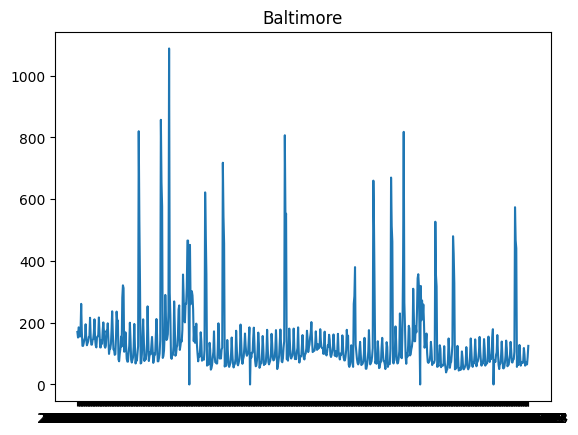

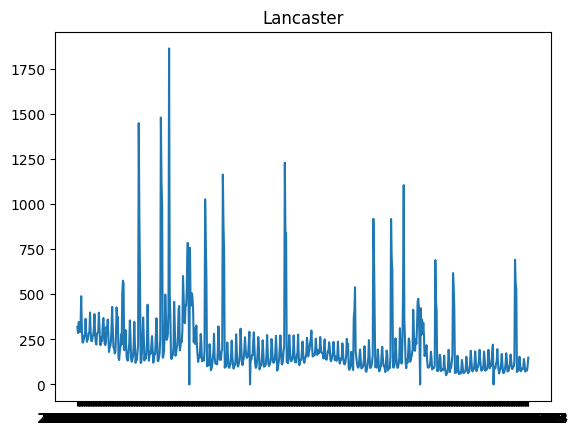

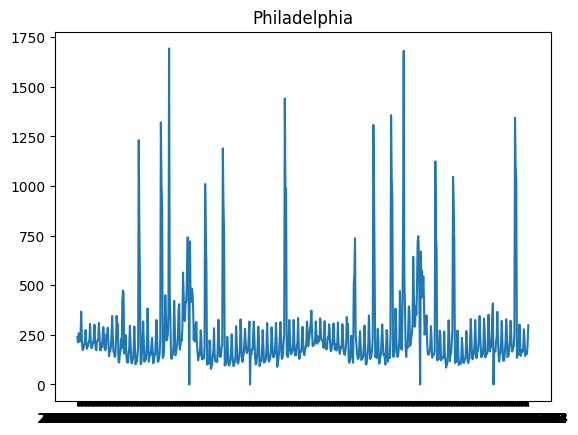

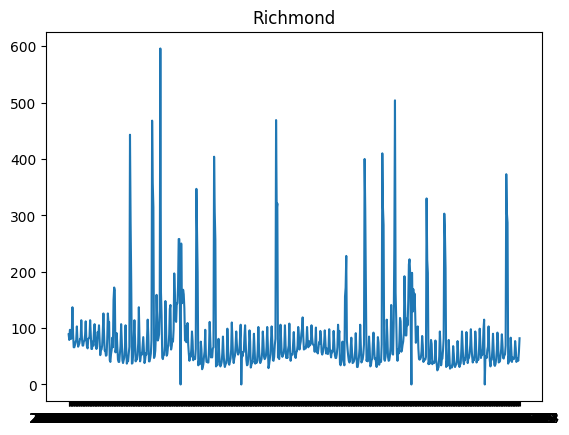

In [14]:
for name, df in [
    ("Baltimore", baltimore),
    ("Lancaster", lancaster),
    ("Philadelphia", philadelphia),
    ("Richmond", richmond)
]:
    plt.figure()
    plt.plot(df['Date'], df['Num_Customers'])
    plt.title(name)
    plt.show()

As lojas apresentam médias, variabilidade e padrões temporais distintos, pelo que os dados devem ser analisados separadamente, garantindo uma modelação mais ajustada a cada contexto.

### 4. Limpeza e Tratamento dos Dados

In [15]:
baltimore_original = baltimore.copy()
lancaster_original = lancaster.copy()
philadelphia_original = philadelphia.copy()
richmond_original = richmond.copy()

In [16]:
def clean_data(df):

    df = df.copy()

    # 1. Datas
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

    # 2. Valores em falta
    df['Pct_On_Sale'] = df['Pct_On_Sale'].interpolate()
    df = df.ffill()

    # 3. Outliers (clipping) com base nos percentis 1% e 99%
    for col in ['Num_Customers', 'Num_Employees', 'Sales']:
        q_low = df[col].quantile(0.01)
        q_high = df[col].quantile(0.99)
        df[col] = df[col].clip(q_low, q_high)

    # 4. Variáveis categóricas
    df['TouristEvent'] = df['TouristEvent'].map({'Yes': 1, 'No': 0})

    return df

In [17]:
# Aplicar Função a todas as lojas
baltimore = clean_data(baltimore)
lancaster = clean_data(lancaster)
philadelphia = clean_data(philadelphia)
richmond = clean_data(richmond)

### 5. Verificar Resultados

In [18]:
# Verificar Valores Ausentes
missing = pd.DataFrame({
    "Baltimore": baltimore.isnull().sum(),
    "Lancaster": lancaster.isnull().sum(),
    "Philadelphia": philadelphia.isnull().sum(),
    "Richmond": richmond.isnull().sum()
})

missing

,Baltimore,Lancaster,Philadelphia,Richmond
Date,0,0,0,0
Num_Employees,0,0,0,0
Num_Customers,0,0,0,0
Pct_On_Sale,0,0,0,0
TouristEvent,0,0,0,0
Sales,0,0,0,0


In [19]:
for name, original_df, cleaned_df in [
    ("Baltimore", baltimore_original, baltimore),
    ("Lancaster", lancaster_original, lancaster),
    ("Philadelphia", philadelphia_original, philadelphia),
    ("Richmond", richmond_original, richmond)
]:

    print(f"\n{name} - Comparação Antes vs Depois:")

    for col in ['Num_Customers', 'Num_Employees', 'Sales']:

        print(f"\n{col}:")

        print("Antes -> Min:", original_df[col].min(), "| Max:", original_df[col].max())
        print("Depois -> Min:", cleaned_df[col].min(), "| Max:", cleaned_df[col].max())


Baltimore - Comparação Antes vs Depois:

Num_Customers:
Antes -> Min: 0 | Max: 1088
Depois -> Min: 47.13 | Max: 659.22

Num_Employees:
Antes -> Min: 0 | Max: 83
Depois -> Min: 7.0 | Max: 53.870000000000005

Sales:
Antes -> Min: 0 | Max: 171345
Depois -> Min: 20502.67 | Max: 88304.39

Lancaster - Comparação Antes vs Depois:

Num_Customers:
Antes -> Min: 0 | Max: 1862
Depois -> Min: 60.13 | Max: 1021.7100000000002

Num_Employees:
Antes -> Min: 0 | Max: 190
Depois -> Min: 9 | Max: 85

Sales:
Antes -> Min: 0 | Max: 298630
Depois -> Min: 27104.28 | Max: 141897.01

Philadelphia - Comparação Antes vs Depois:

Num_Customers:
Antes -> Min: 0 | Max: 1693
Depois -> Min: 89.39 | Max: 1225.67

Num_Employees:
Antes -> Min: 0 | Max: 184
Depois -> Min: 14.0 | Max: 109.61000000000001

Sales:
Antes -> Min: 0 | Max: 252073
Depois -> Min: 43814.17 | Max: 153503.66

Richmond - Comparação Antes vs Depois:

Num_Customers:
Antes -> Min: 0 | Max: 596
Depois -> Min: 28.13 | Max: 396.4900000000001

Num_Employee

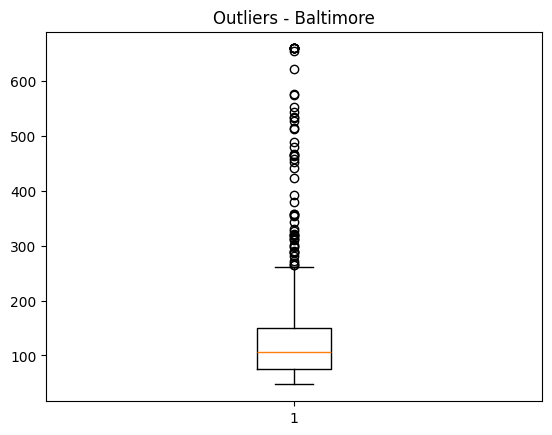

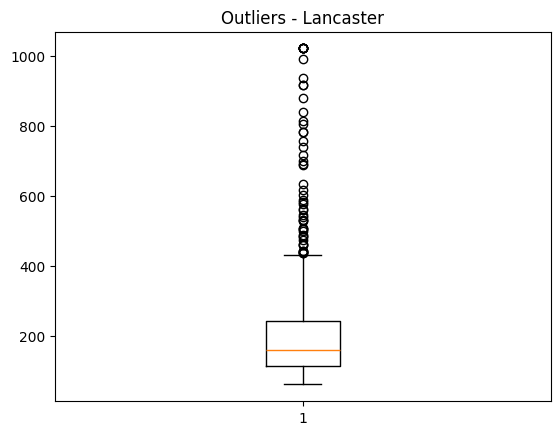

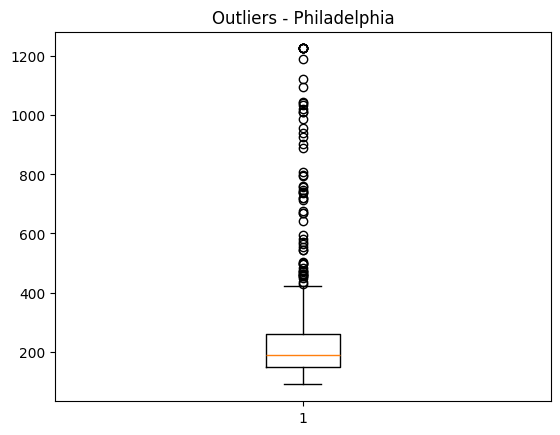

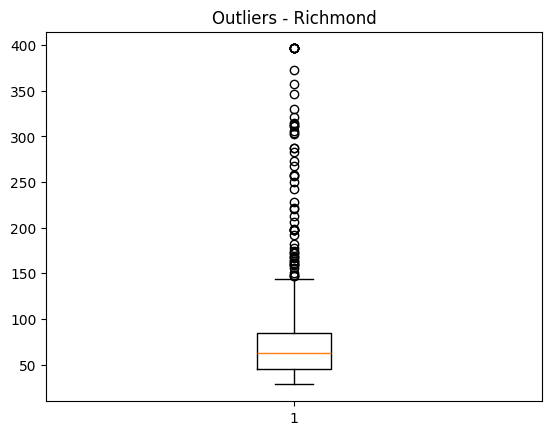

In [20]:
# Verificar Outliers
for name, df in {
    "Baltimore": baltimore,
    "Lancaster": lancaster,
    "Philadelphia": philadelphia,
    "Richmond": richmond
}.items():

    plt.figure()
    plt.boxplot(df['Num_Customers'])
    plt.title(f"Outliers - {name}")
    plt.show()

A comparação entre os dados antes e após a limpeza demonstra que os valores extremos foram efetivamente limitados, reduzindo a dispersão sem perda de informação relevante.